# CMR Mine Locations (current and planned mines)

In [1]:
import numpy as np
import pandas as pd

import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

import rasterio
from rasterio.merge import merge
from rasterio.mask import mask

import osmnx as ox

## data cleaning

In [2]:
# data from excel
current_mines_xlsx_path= Path("../data/input/mine-location-data/ahmed-ssa-mine-locations/All Mines SSA_469.xlsx")
current_mines_df = pd.read_excel(current_mines_xlsx_path, sheet_name="All Mines SSA_469")
current_mines_df.columns

Index(['Mine_ID', 'COUNTRY_ID', 'COMMODITY', 'MINE_OPERA', 'LAT_Y', 'LONG_X',
       'YEAR_ESTD', 'MINE_NAME'],
      dtype='object')

In [3]:
### load CURRENT mines data ###
# data from excel
current_mines_xlsx_path= Path("../data/input/mine-location-data/ahmed-ssa-mine-locations/All Mines SSA_469.xlsx")
current_mines_df = pd.read_excel(current_mines_xlsx_path, sheet_name="All Mines SSA_469")
commodity_code_df = pd.read_excel(current_mines_xlsx_path, sheet_name="Commodities_Code")

# data from shapefile
current_mines_shp_path = Path("../data/input/mine-location-data/ahmed-ssa-mine-locations/All_469_Mines/ALL_469_MINES_IN_SSA.shp")
current_mines_shp_df = gpd.read_file(current_mines_shp_path)

# filter out mines outside Cameroon (COUNTRY_ID = 07)
country_id = 7
current_mines_df = current_mines_df[current_mines_df["COUNTRY_ID"] == country_id]
print(f"number of built mines in Cameroon is {len(current_mines_df)}")

# add a commodity_name column to the current_mines_df and map its 'COMMODITY' column to the commodity_code_df's 'COMMODITY' column to get the data from 'CODE' column
current_mines_df["commodity_name"] = current_mines_df["COMMODITY"].map(
    commodity_code_df.set_index("CODE")["COMMODITY"]
)

### load planned mine data ###
planned_mines_xlsx_path = Path("../data/input/mine-location-data/planned-mine-locations/Mining Dataset Capital IQ 11Nov2023.xlsx")
planned_mines_df = pd.read_excel(planned_mines_xlsx_path, sheet_name="Sheet1")

# filter only mines in Cameroon (COUNTRY_NAME == "Cameroon")
planned_mines_df = planned_mines_df[planned_mines_df["COUNTRY_NAME"] == "Cameroon"]
print(f"number of planned mines in Cameroon is {len(planned_mines_df)}")

# clean the table 
# rename the columns in the planned_mines_df to be more consistent with the current_mines_df's columns
current_mines_df = current_mines_df.rename(columns={
    "LAT_Y": "LATITUDE",
    "LONG_X": "LONGITUDE",
    "commodity_name": "PRIMARY_COMMODITY",
    "MINE_NAME": "PROP_NAME",
    "Mine_ID": "PROP_ID",
    "YEAR_ESTD": "START_UP_YR"
})

# add a new column called 'planned mine' to the current_mines_df and set it to 0 for all rows
current_mines_df["planned_mine"] = 0
# add a new column called 'planned mine' to the planned_mines_df and set it to 1 for all rows if START_UP_YR == Nan
planned_mines_df["planned_mine"] = np.where(planned_mines_df["START_UP_YR"].isna(), 1, 0)


# merge the current_mines_df and planned_mines_df into one dataframe called all_mines_df
# use the planned_mines_df's columns as the base and add the current_mines_df's columns to it
all_mines_df = pd.concat([planned_mines_df, current_mines_df], ignore_index=True, sort=False)
print(f"number of all mines in Cameroon is {len(all_mines_df)}")

# change the data in the 'all_mines_df' column to be more consistent with the current_mines_df's 'all_mines_df' column
all_mines_df["PRIMARY_COMMODITY"] = all_mines_df["PRIMARY_COMMODITY"].str.lower().str.strip().str.replace(" - ", " ")

# in the 'PRIMARY_COMMODITY' column, replace all instances of "u3o8" with "uranium"
all_mines_df["PRIMARY_COMMODITY"] = all_mines_df["PRIMARY_COMMODITY"].str.replace("u3o8", "uranium")
all_mines_df["PRIMARY_COMMODITY"] = all_mines_df["PRIMARY_COMMODITY"].str.replace("diamonds", "diamond")

all_mines_df = all_mines_df.drop(columns=["COUNTRY_ID", "COMMODITY", "COUNTRY_NAME"])

# create a change log column to be used for tracking changes made to the data
all_mines_df["change_log"] = ""

number of built mines in Cameroon is 13
number of planned mines in Cameroon is 31
number of all mines in Cameroon is 44


In [4]:
planned_mines_df.columns

Index(['PROP_NAME', 'PROP_ID', 'PRIMARY_COMMODITY', 'DEV_STAGE',
       'MINESEARCH_ID', 'LATITUDE', 'LONGITUDE', 'COORDINATE_ACCURACY',
       'STATE_PROVINCE', 'COUNTRY_NAME', 'START_UP_YR', 'ACTUAL_CLOSURE_YR',
       'EVENT_YR', 'Mine in Protected Area', 'planned_mine'],
      dtype='object')

In [5]:
all_mines_df.columns

Index(['PROP_NAME', 'PROP_ID', 'PRIMARY_COMMODITY', 'DEV_STAGE',
       'MINESEARCH_ID', 'LATITUDE', 'LONGITUDE', 'COORDINATE_ACCURACY',
       'STATE_PROVINCE', 'START_UP_YR', 'ACTUAL_CLOSURE_YR', 'EVENT_YR',
       'Mine in Protected Area', 'planned_mine', 'MINE_OPERA', 'change_log'],
      dtype='object')

In [6]:
### load administrative boundary data ###
# set this to the folder where you unzipped the files
data_dir = Path(r"../data/input/cmr_admin_boundaries_humdata")

# read shapefiles for each admin level
adm1 = gpd.read_file(data_dir / "cmr_admin1.shp")
adm2 = gpd.read_file(data_dir / "cmr_admin2.shp")
adm3 = gpd.read_file(data_dir / "cmr_admin3.shp")

# quick check: print table size
print("adm1 shape:", adm1.shape)
print("adm2 shape:", adm2.shape)
print("adm3 shape:", adm3.shape)

adm1 shape: (10, 22)
adm2 shape: (58, 27)
adm3 shape: (360, 32)


In [7]:
# fill data the STATE_PROVINCE column to all_mines_df based on the latitude and longitude of the mines and the adm1 shapefile
# use adm1_name_col to get the name of the admin-1 region for each mine

all_mines_gdf = gpd.GeoDataFrame(
    all_mines_df,
    geometry=gpd.points_from_xy(all_mines_df["LONGITUDE"], all_mines_df["LATITUDE"]),
    crs="EPSG:4326"
)

adm1_for_join = adm1.to_crs(all_mines_gdf.crs)

# detect admin-1 name column safely (avoids KeyError: '[None] not in index')
candidate_cols = ["adm1_name"]
adm1_name_col = next((c for c in candidate_cols if c in adm1_for_join.columns), None)

if adm1_name_col is None:
    object_cols = [c for c in adm1_for_join.columns if c != "geometry" and adm1_for_join[c].dtype == "object"]
    if not object_cols:
        raise KeyError(f"Could not find an admin-1 name column in adm1. Columns: {list(adm1_for_join.columns)}")
    adm1_name_col = object_cols[0]

adm1_lookup = adm1_for_join[[adm1_name_col, "geometry"]].rename(
    columns={adm1_name_col: "STATE_PROVINCE_FROM_ADM1"}
)

state_join = gpd.sjoin(
    all_mines_gdf[["geometry"]],
    adm1_lookup,
    how="left",
    predicate="intersects"
)

state_by_mine = state_join.groupby(level=0)["STATE_PROVINCE_FROM_ADM1"].first()

if "STATE_PROVINCE" not in all_mines_df.columns:
    all_mines_df["STATE_PROVINCE"] = pd.NA

# always overwrite existing STATE_PROVINCE values with the spatial-join result
all_mines_df["STATE_PROVINCE"] = state_by_mine.reindex(all_mines_df.index)

# if DEV_STAGE == NaN and planned_mine == 0, set to 'Operations' else do not change it
all_mines_df["change_log"] = np.where(
    (all_mines_df["DEV_STAGE"].isna()) & (all_mines_df["planned_mine"] == 0),
    all_mines_df["change_log"] + "built mine without DEV_STAGE -- filled with 'Operations'; ",
    all_mines_df["change_log"]
)
all_mines_df["DEV_STAGE"] = np.where(
    (all_mines_df["DEV_STAGE"].isna()) & (all_mines_df["planned_mine"] == 0),
    "Operations",
    all_mines_df["DEV_STAGE"]
)

# if DEV_STAGE == NaN and planned_mine == 1, set to 'Exploration' else do not change it; also add "missing DEV_STAGE" to the change log for these rows
all_mines_df["change_log"] = np.where(
    (all_mines_df["DEV_STAGE"].isna()) & (all_mines_df["planned_mine"] == 1),
    all_mines_df["change_log"] + "planned mine but missing DEV_STAGE -- filled with 'Exploration'; ",
    all_mines_df["change_log"]
)
all_mines_df["DEV_STAGE"] = np.where(
    (all_mines_df["DEV_STAGE"].isna()) & (all_mines_df["planned_mine"] == 1),
    "Exploration",
    all_mines_df["DEV_STAGE"]
)

# aggreate DEV_STAGE
dev_stage_mapping_SNL = {
    "Early-stage": ["Grassroots", "Exploration", "Target Outline", "Advanced Exploration"],
    "Late-stage": ["Reserves Development", "Feasibility", 'Prefeas/Scoping', "Feasibility Complete"],
    "Mine-stage": ["Preproduction", "Construction Started", "Operations"],}

# add a new column called DEV_STAGE_AGGREGATED_SNL to the all_mines_df and map the DEV_STAGE column to the dev_stage_mapping_SNL dictionary
all_mines_df["DEV_STAGE_AGGREGATED_SNL"] = all_mines_df["DEV_STAGE"].map(
    lambda x: next((agg for agg, stages in dev_stage_mapping_SNL.items() if x in stages), x)
)

# if a row's DEV_STAGE_AGGREGATED_SNL == 'Mine-stage' but 'planned_mine' == 1, add the note "inconsistent DEV_STAGE_AGGREGATED_SNL and planned_mine -- changed planned_mine to 0" to the change log and change planned_mine to 0
all_mines_df["change_log"] = np.where(
    (all_mines_df["DEV_STAGE_AGGREGATED_SNL"] == "Mine-stage") & (all_mines_df["planned_mine"] == 1),
    all_mines_df["change_log"] + "inconsistent DEV_STAGE_AGGREGATED_SNL and planned_mine -- changed planned_mine to 0; ",
    all_mines_df["change_log"]
)
all_mines_df["planned_mine"] = np.where(
    (all_mines_df["DEV_STAGE_AGGREGATED_SNL"] == "Mine-stage") & (all_mines_df["planned_mine"] == 1),
    0,
    all_mines_df["planned_mine"]
)


In [8]:
### load protected areas data ###
protected_areas_polygon_path = Path(r"../data/output/processed-protected-areas/cmr-protected-areas.gpkg")
protected_areas_gdf = gpd.read_file(protected_areas_polygon_path)

# Perform spatial join to determine if mines are in protected areas
all_mines_gdf = gpd.GeoDataFrame(
    all_mines_df,
    geometry=gpd.points_from_xy(all_mines_df["LONGITUDE"], all_mines_df["LATITUDE"]),
    crs="EPSG:4326"
)

# Ensure protected areas have same CRS
protected_areas_gdf = protected_areas_gdf.to_crs(all_mines_gdf.crs)

# Spatial join: check if each mine intersects with protected areas
mines_in_pa = gpd.sjoin(
    all_mines_gdf[["geometry"]],
    protected_areas_gdf[["geometry"]],
    how="left",
    predicate="intersects"
)

# Mark mines that intersect with protected areas
all_mines_df["MINE_IN_PROTECTED_AREA"] = mines_in_pa.index.duplicated(keep=False).astype(str)

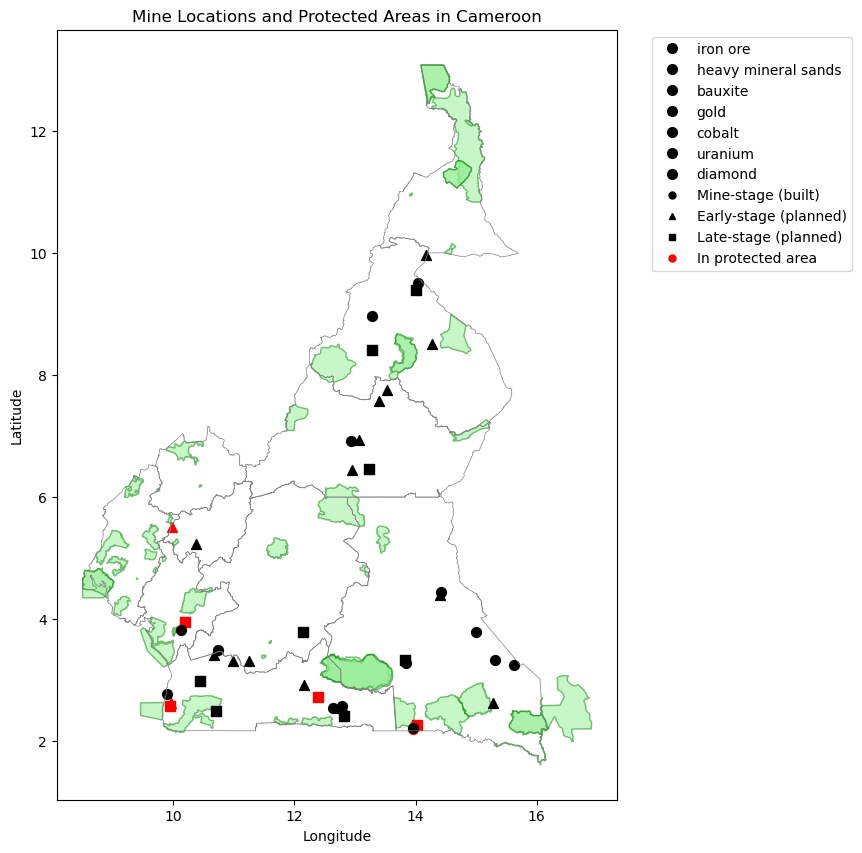

In [9]:
# validation plot to check the locations of the mines and protected areas
fig, ax = plt.subplots(figsize=(10, 10))

protected_areas_gdf.plot(ax=ax, color="lightgreen", edgecolor="green", alpha=0.5)
adm1.boundary.plot(ax=ax, color="gray", linewidth=0.5)

commodities = all_mines_df["PRIMARY_COMMODITY"].dropna().unique()
color_handles = [
    plt.Line2D([0], [0], marker="o", color="black", linestyle="None", markersize=7, label=c)
    for c in commodities
]

shape_handles = [
    plt.Line2D([0], [0], marker="o", color="black", linestyle="None", markersize=5, label="Mine-stage (built)"),
    plt.Line2D([0], [0], marker="^", color="black", linestyle="None", markersize=5, label="Early-stage (planned)"),
    plt.Line2D([0], [0], marker="s", color="black", linestyle="None", markersize=5, label="Late-stage (planned)"),
    plt.Line2D([0], [0], marker="o", color="red", linestyle="None", markersize=5, label="In protected area"),
]

for _, row in all_mines_df.iterrows():
    if row["planned_mine"] == 0:
        marker = "o"
    elif row["DEV_STAGE_AGGREGATED_SNL"] == "Early-stage":
        marker = "^"
    elif row["DEV_STAGE_AGGREGATED_SNL"] == "Late-stage":
        marker = "s"
    else:
        marker = "o"

    in_pa = str(row.get("Mine in Protected Area", "")).strip().lower() == "yes"
    color = "red" if in_pa else "black"

    ax.scatter(row["LONGITUDE"], row["LATITUDE"], color=color, marker=marker, s=50)

ax.legend(handles=color_handles + shape_handles, bbox_to_anchor=(1.05, 1), loc="upper left")
ax.set_title("Mine Locations and Protected Areas in Cameroon")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

In [10]:
all_mines_df["DEV_STAGE"].value_counts(dropna=False)

DEV_STAGE
Operations              13
Exploration              9
Grassroots               5
Reserves Development     5
Prefeas/Scoping          4
Target Outline           2
Feasibility              2
Advanced Exploration     1
Construction Started     1
Feasibility Complete     1
Preproduction            1
Name: count, dtype: int64

In [11]:
all_mines_df["DEV_STAGE_AGGREGATED_SNL"].value_counts(dropna=False)

DEV_STAGE_AGGREGATED_SNL
Early-stage    17
Mine-stage     15
Late-stage     12
Name: count, dtype: int64

In [12]:
all_mines_df["Mine in Protected Area"].value_counts()

Mine in Protected Area
Yes    7
Name: count, dtype: int64

In [13]:
all_mines_df["MINE_IN_PROTECTED_AREA"].value_counts()

MINE_IN_PROTECTED_AREA
False    44
Name: count, dtype: int64

## data save

In [14]:
# save the all_mines_df to a csv file
all_mines_df.to_csv("../data/output/all_mines_df.csv", index=False)

## data exploration

In [2]:
# load cleaned all_mines_df from the csv file
all_mines_df = pd.read_csv("../data/output/all_mines_df.csv")

In [3]:
all_mines_df

,PROP_NAME,PROP_ID,PRIMARY_COMMODITY,DEV_STAGE,MINESEARCH_ID,LATITUDE,LONGITUDE,COORDINATE_ACCURACY,STATE_PROVINCE,START_UP_YR,ACTUAL_CLOSURE_YR,EVENT_YR,Mine in Protected Area,planned_mine,MINE_OPERA,change_log,DEV_STAGE_AGGREGATED_SNL,MINE_IN_PROTECTED_AREA
0,Akonolinga,51028,iron ore,Exploration,NaN,2.91626,12.16394,Exact,South,NaN,NaN,NaN,NaN,1,NaN,NaN,Early-stage,False
1,Akonolinga,52788,heavy mineral sands,Prefeas/Scoping,NaN,3.78500,12.13800,Exact,Centre,NaN,NaN,NaN,NaN,1,NaN,NaN,Late-stage,False
2,Bangou,65981,bauxite,Grassroots,NaN,5.24000,10.37000,Approximate,West,NaN,NaN,NaN,NaN,1,NaN,NaN,Early-stage,False
3,Batouri,36389,gold,Exploration,118162.0,4.39820,14.40665,Exact,East,NaN,NaN,NaN,NaN,1,NaN,NaN,Early-stage,False
4,Bibemi,50432,gold,Reserves Development,125428.0,9.38893,14.00665,Exact,North,NaN,NaN,NaN,NaN,1,NaN,NaN,Late-stage,False
5,Bikoula,65982,iron ore,Reserves Development,NaN,2.72278,12.39601,Exact,South,NaN,NaN,NaN,Yes,1,NaN,NaN,Late-stage,False
6,Binga,40778,iron ore,Reserves Development,123419.0,2.49806,10.70806,Exact,South,NaN,NaN,NaN,NaN,1,NaN,NaN,Late-stage,False
7,Birsok,65980,bauxite,Target Outline,NaN,6.93000,13.07000,Exact,Adamawa,NaN,NaN,NaN,NaN,1,NaN,NaN,Early-stage,False
8,Cameroon East,32667,cobalt,Feasibility,113860.0,3.33306,13.83333,Exact,East,NaN,NaN,NaN,NaN,1,NaN,NaN,Late-stage,False
9,CLP,90901,gold,Exploration,NaN,7.75841,13.52388,Exact,Adamawa,NaN,NaN,NaN,NaN,1,NaN,NaN,Early-stage,False


In [4]:
### load road network data ###
road_shp_path = Path(r"../data/input/Road_network/cmr-roads-liu-2025/Cameroon.shp")
cameroon_roads = gpd.read_file(road_shp_path)
cameroon_roads.head()

,ID,Start_pt,End_pt,Rd_length,Surface,data_src,geometry
0,1,"(1103991.702615, 328198.947937)","(1103520.286835, 328787.695206)",762.730176,paved,liu,"MULTILINESTRING ((1103991.703 328198.948, 1103..."
1,2,"(1103520.286835, 328787.695206)","(1103479.510506, 327812.637704)",980.028403,paved,liu,"MULTILINESTRING ((1103520.287 328787.695, 1103..."
2,3,"(1094496.606460, 264352.420784)","(1094836.587317, 264478.208504)",364.363710,paved,liu,"MULTILINESTRING ((1094496.606 264352.421, 1094..."
3,4,"(1102316.032584, 283330.554237)","(1101453.228606, 267250.567070)",23257.130654,unpaved,liu,"MULTILINESTRING ((1102316.033 283330.554, 1102..."
4,5,"(1103057.420392, 327326.354672)","(1102985.552529, 327212.146541)",134.938827,paved,liu,"LINESTRING (1103057.42 327326.355, 1102985.553..."


In [5]:
### load administrative boundary data ###
# set this to the folder where you unzipped the files
data_dir = Path(r"../data/input/cmr_admin_boundaries_humdata")

# read shapefiles for each admin level
adm1 = gpd.read_file(data_dir / "cmr_admin1.shp")
adm2 = gpd.read_file(data_dir / "cmr_admin2.shp")
adm3 = gpd.read_file(data_dir / "cmr_admin3.shp")

# quick check: print table size
print("adm1 shape:", adm1.shape)
print("adm2 shape:", adm2.shape)
print("adm3 shape:", adm3.shape)

adm1 shape: (10, 22)
adm2 shape: (58, 27)
adm3 shape: (360, 32)


In [6]:
### load protected areas data ###
protected_areas_polygon_path = Path(r"../data/output/processed-protected-areas/cmr-protected-areas.gpkg")
protected_areas_gdf = gpd.read_file(protected_areas_polygon_path)

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


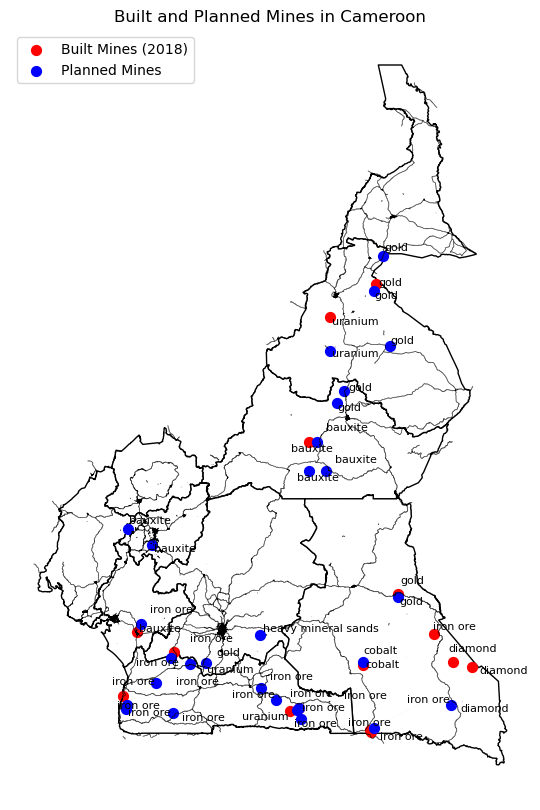

In [7]:
from adjustText import adjust_text

### plot the all_mines_df and roads on the map (administrative boundaries level 1) ###

# make a copy of the all_mines_df and convert it to a GeoDataFrame
all_mines_gdf = gpd.GeoDataFrame(
    all_mines_df,
    geometry=gpd.points_from_xy(all_mines_df["LONGITUDE"], all_mines_df["LATITUDE"]),
    crs="EPSG:4326"
)

# transform the road crs to match the all_mines_gdf's crs
cameroon_roads = cameroon_roads.to_crs(all_mines_gdf.crs)

#  use different color for built mines and planned mines
fig, ax = plt.subplots(figsize=(10, 10))
adm1.plot(ax=ax, color="white", edgecolor="black")
main_roads = cameroon_roads[cameroon_roads["Surface"] == "paved"]
main_roads.plot(ax=ax, color="black", linewidth=0.5)
all_mines_gdf[all_mines_gdf["planned_mine"] == 0].plot(ax=ax, color="red", markersize=50, label="Built Mines (2018)")
all_mines_gdf[all_mines_gdf["planned_mine"] == 1].plot(ax=ax, color="blue", markersize=50, label="Planned Mines")

# add 'PRIMARY_COMMODITY' as text label for each mine; append START_UP_YR if available
texts = []
for _, row in all_mines_gdf.iterrows():
    label = row["PRIMARY_COMMODITY"]
    # year = row["START_UP_YR"]
    # if pd.notna(year) and year != 0:
        # label = f"{label} {int(year)}"
    texts.append(ax.text(row.geometry.x, row.geometry.y, label, fontsize=8))

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="lightgray", lw=0.2, alpha=0.3),
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.4),
    force_text=(0.3, 0.5)
)
    
plt.legend(loc="upper left")
plt.title("Built and Planned Mines in Cameroon")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis("off")
plt.show()

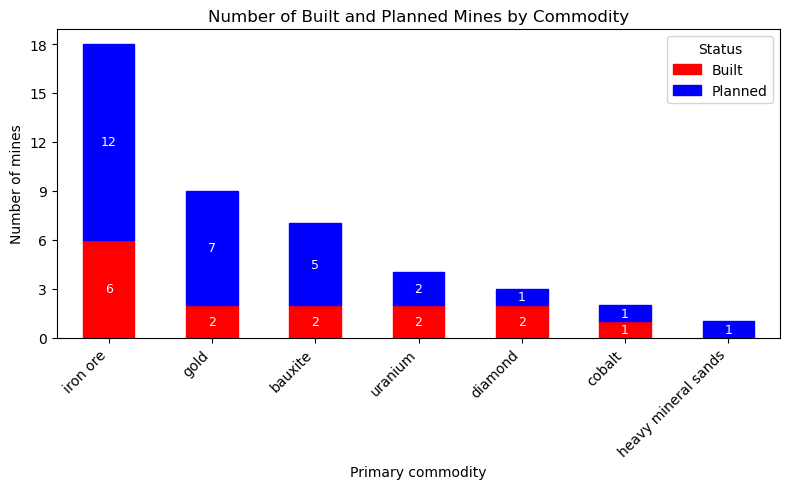

In [8]:
### create a stacked bar chart to show the number of built mines and planned mines by commodity type ###
# group the all_mines_df by 'PRIMARY_COMMODITY' and 'planned_mine' and count the number of mines in each group
mine_counts = (
    all_mines_df.groupby(["PRIMARY_COMMODITY", "planned_mine"])
    .size()
    .unstack(fill_value=0)
)

# sort commodities by total number of mines (planned + built), descending
mine_counts = mine_counts.loc[mine_counts.sum(axis=1).sort_values(ascending=False).index]

ax = mine_counts.plot(kind="bar", stacked=True, figsize=(8, 5))

# set color for built and planned bars
colors = ["red", "blue"]  # red for built, blue for planned
for i, bar in enumerate(ax.containers):
    plt.setp(bar, color=colors[i])

# optional: clearer legend labels for built_mine values (0=built, 1=planned)
ax.legend(["Built", "Planned"], title="Status")

# label each stack segment with its count
for container in ax.containers:
    labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=9, color="white")

plt.ylabel("Number of mines")
plt.xlabel("Primary commodity")
plt.xticks(rotation=45, ha="right")
plt.yticks(range(0, 19, 3))
plt.title("Number of Built and Planned Mines by Commodity")
plt.tight_layout()

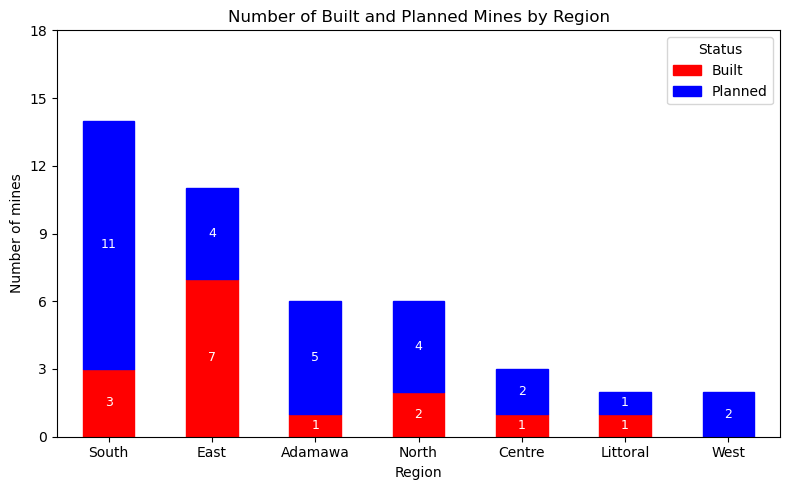

In [9]:
mine_counts = (
    all_mines_df.groupby(["STATE_PROVINCE", "planned_mine"])
    .size()
    .unstack(fill_value=0)
)

# sort commodities by total number of mines (planned + built), descending
mine_counts = mine_counts.loc[mine_counts.sum(axis=1).sort_values(ascending=False).index]

ax = mine_counts.plot(kind="bar", stacked=True, figsize=(8, 5))

# set color for built and planned bars
colors = ["red", "blue"]  # red for built, blue for planned
for i, bar in enumerate(ax.containers):
    plt.setp(bar, color=colors[i])

# optional: clearer legend labels for built_mine values (0=built, 1=planned)
ax.legend(["Built", "Planned"], title="Status")

# label each stack segment with its count
for container in ax.containers:
    labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=9, color="white")

plt.ylabel("Number of mines")
plt.xlabel("Region")
plt.xticks(rotation=0, ha="center")
plt.yticks(range(0, 19, 3))
plt.title("Number of Built and Planned Mines by Region")
plt.tight_layout()

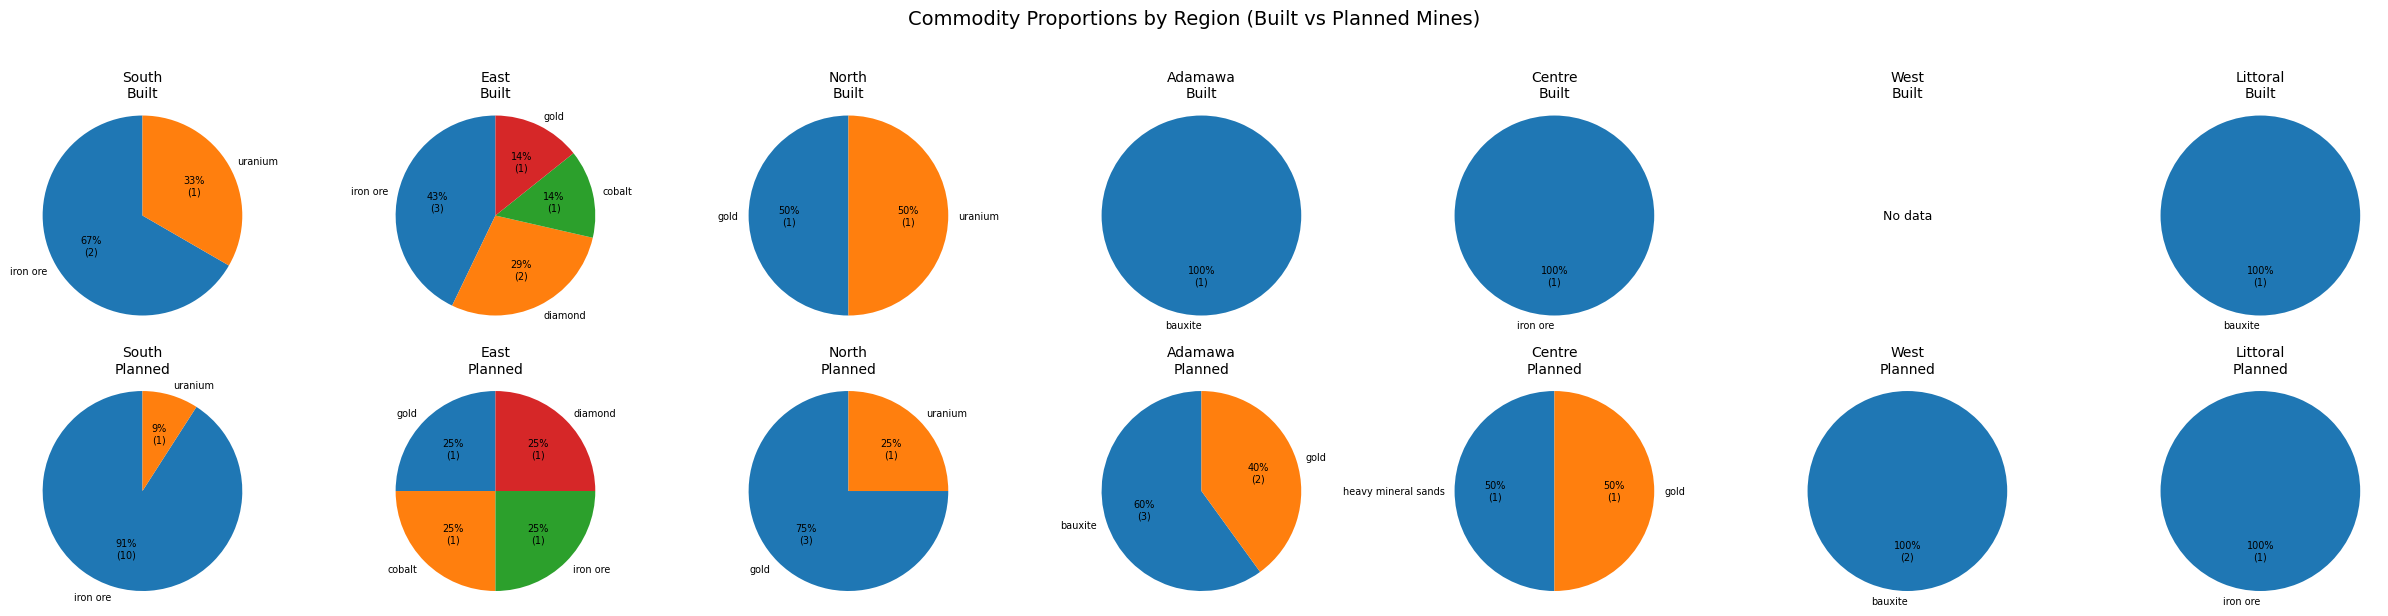

In [10]:
# plot 2 x 10 pie charts:
# row 0 = Built, row 1 = Planned
# columns = up to 10 regions

top_regions = (
    all_mines_df["STATE_PROVINCE"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

fig, axes = plt.subplots(nrows=2, ncols=7, figsize=(24, 6))
status_map = {0: "Built", 1: "Planned"}

for c in range(7):
    for r, status in enumerate([0, 1]):
        ax = axes[r, c]

        # hide columns beyond available regions
        if c >= len(top_regions):
            ax.axis("off")
            continue

        region = top_regions[c]
        counts = (
            all_mines_df[
                (all_mines_df["STATE_PROVINCE"] == region) &
                (all_mines_df["planned_mine"] == status)
            ]["PRIMARY_COMMODITY"]
            .value_counts()
        )

        if counts.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=9)
            ax.set_title(f"{region}\n{status_map[status]}", fontsize=10)
            ax.axis("off")
        else:
            total = counts.sum()
            ax.pie(
                counts.values,
                labels=counts.index,
                autopct=lambda pct: f"{pct:.0f}%\n({int(round(pct * total / 100.0))})",
                startangle=90,
                textprops={"fontsize": 7}
            )
            ax.set_title(f"{region}\n{status_map[status]}", fontsize=10)
            ax.axis("equal")

plt.suptitle("Commodity Proportions by Region (Built vs Planned Mines)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\Move\AppData\Local\Temp\ipykernel_40868\3855600171.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(commodities))


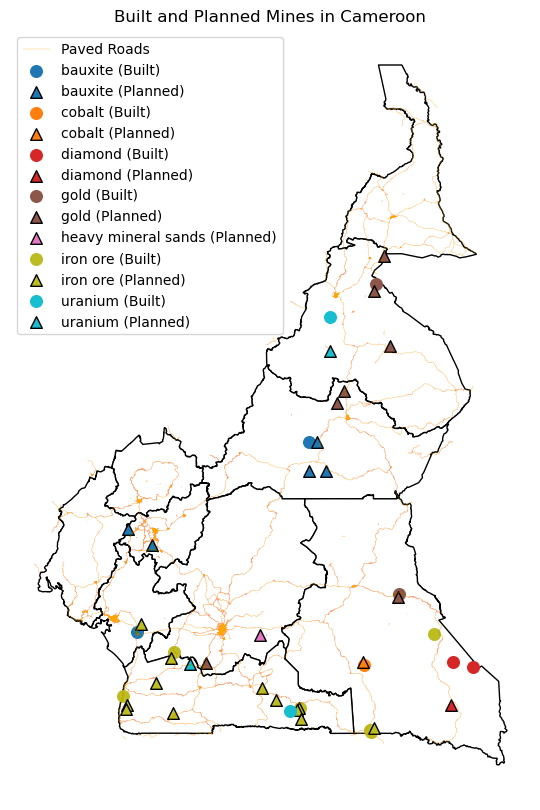

In [11]:
from adjustText import adjust_text

### plot the all_mines_df and roads on the map (administrative boundaries level 1) ###

# make a copy of the all_mines_df and convert it to a GeoDataFrame
all_mines_gdf = gpd.GeoDataFrame(
    all_mines_df,
    geometry=gpd.points_from_xy(all_mines_df["LONGITUDE"], all_mines_df["LATITUDE"]),
    crs="EPSG:4326"
)

# transform the road crs to match the all_mines_gdf's crs
cameroon_roads = cameroon_roads.to_crs(all_mines_gdf.crs)

# plot main roads
fig, ax = plt.subplots(figsize=(10, 10))
adm1.plot(ax=ax, color="white", edgecolor="black")
main_roads = cameroon_roads[cameroon_roads["Surface"] == "paved"]
main_roads.plot(ax=ax, color="orange", linewidth=0.2, label="Paved Roads")

# plot mines by commodity type in different colors
commodities = sorted(all_mines_gdf["PRIMARY_COMMODITY"].dropna().unique())
cmap = plt.cm.get_cmap("tab10", len(commodities))
commodity_colors = {commodity: cmap(i) for i, commodity in enumerate(commodities)}

for commodity in commodities:
    subset = all_mines_gdf[all_mines_gdf["PRIMARY_COMMODITY"] == commodity]
    built_subset = subset[subset["planned_mine"] == 0]
    planned_subset = subset[subset["planned_mine"] == 1]

    color = commodity_colors[commodity]

    if not built_subset.empty:
        built_subset.plot(
            ax=ax,
            color=color,
            alpha=1.0,
            markersize=70,
            label=f"{commodity} (Built)"
        )

    if not planned_subset.empty:
        planned_subset.plot(
            ax=ax,
            color=color,
            alpha=1.0,
            markersize=70,
            marker="^",
            edgecolor="black",
            label=f"{commodity} (Planned)"
        )



# add 'PRIMARY_COMMODITY' as text label for each mine; append START_UP_YR if available
# texts = []
# for _, row in all_mines_gdf.iterrows():
#     label = row["PRIMARY_COMMODITY"]
#     # year = row["START_UP_YR"]
#     # if pd.notna(year) and year != 0:
#         # label = f"{label} {int(year)}"
#     texts.append(ax.text(row.geometry.x, row.geometry.y, label, fontsize=8))

# adjust_text(
#     texts,
#     ax=ax,
#     arrowprops=dict(arrowstyle="-", color="lightgray", lw=0.2, alpha=0.3),
#     expand_points=(1.2, 1.2),
#     expand_text=(1.2, 1.4),
#     force_text=(0.3, 0.5)
# )
    
plt.legend(loc="upper left")
plt.title("Built and Planned Mines in Cameroon")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis("off")
plt.show()

In [12]:
# port locations in lat lon

port_locations = {
    'Kribi': (2.9192, 9.8636),    # Deepwater port [web:22][web:1]
    'Douala': (4.0500, 9.6972),   # Main port CMDLA [web:19][web:20]
    'Limbe': (4.0236, 9.2061),    # Minor port CMLIM [web:7][web:30]
}

C:\Users\Move\AppData\Local\Temp\ipykernel_40868\3741136346.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(commodities))


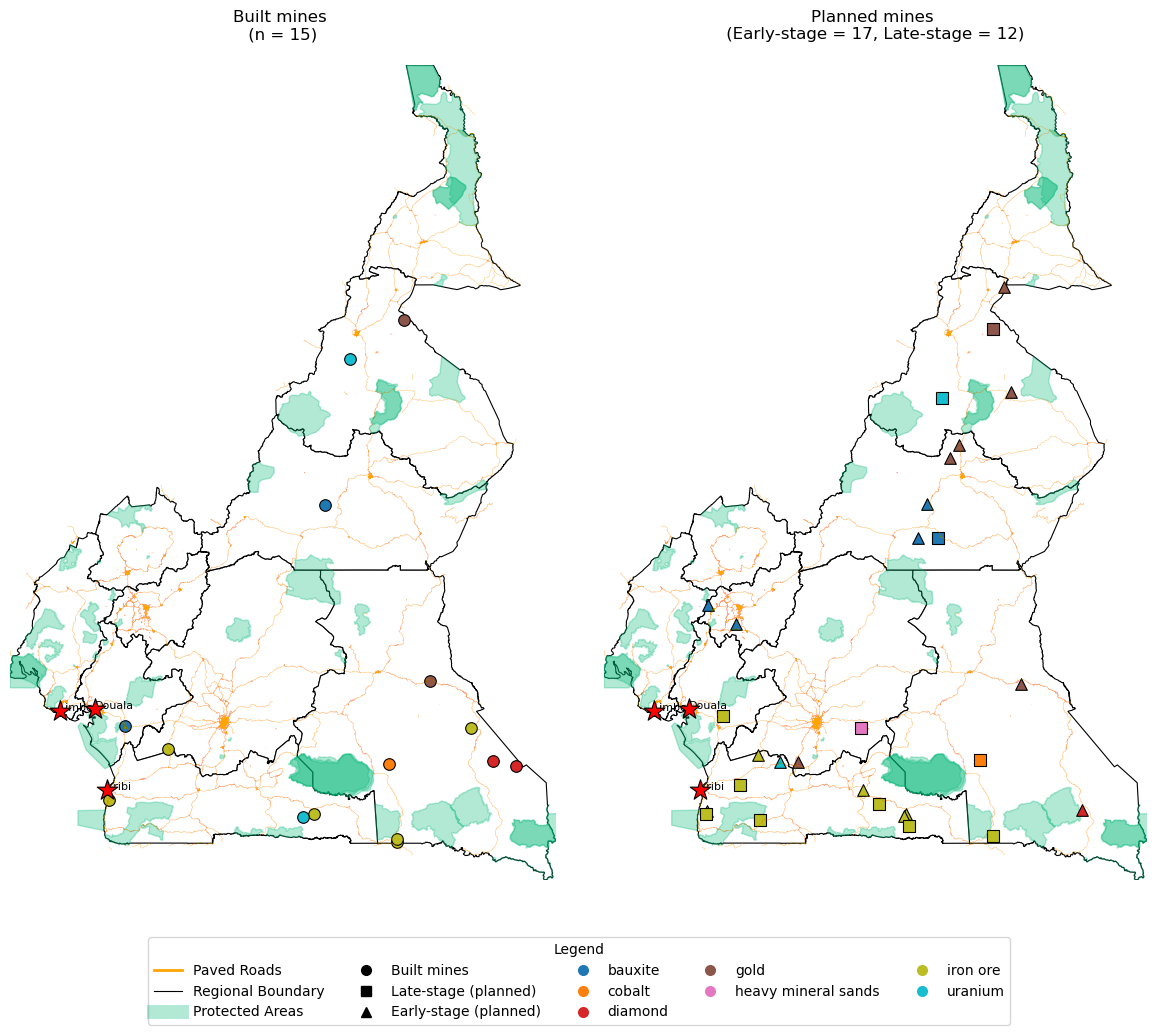

In [13]:
# consistent colors by commodity across both panels
commodities = sorted(all_mines_gdf["PRIMARY_COMMODITY"].dropna().unique())
cmap = plt.cm.get_cmap("tab10", len(commodities))
commodity_colors = {c: cmap(i) for i, c in enumerate(commodities)}

fig, axes = plt.subplots(1, 2, figsize=(12, 10), sharex=True, sharey=True)

# common map extent
xmin, ymin, xmax, ymax = adm1.total_bounds

# LEFT: built mines (round markers)
ax_left = axes[0]
adm1.plot(ax=ax_left, color="white", edgecolor="black", linewidth=0.8)

# plot protected areas on the left panel
protected_areas_gdf.plot(ax=ax_left, color="#00b777", edgecolor="#00b777", alpha=0.3, label="Protected Areas")

# plot main roads on both panels for context
main_roads = cameroon_roads[cameroon_roads["Surface"] == "paved"]
main_roads.plot(ax=ax_left, color="orange", linewidth=0.2, label="Paved Roads")

built = all_mines_gdf[all_mines_gdf["DEV_STAGE_AGGREGATED_SNL"] == "Mine-stage"]
for c in commodities:
    s = built[built["PRIMARY_COMMODITY"] == c]
    if not s.empty:
        s.plot(ax=ax_left, color=commodity_colors[c], markersize=70, marker="o", edgecolor="black", linewidth=0.8)

# ax_left.set_title("Built Mines")
ax_left.set_title(f"Built mines \n (n = {len(built)}) \n", fontsize=12)
ax_left.set_xlim(xmin, xmax)
ax_left.set_ylim(ymin, ymax)
ax_left.axis("off")

# RIGHT: planned mines (triangle markers)
ax_right = axes[1]
adm1.plot(ax=ax_right, color="white", edgecolor="black", linewidth=0.8)

# plot main roads on both panels for context
main_roads.plot(ax=ax_right, color="orange", linewidth=0.2, label="Paved Roads")

# plot protected areas on the right panel
protected_areas_gdf.plot(ax=ax_right, color="#00b777", edgecolor="#00b777", alpha=0.3, label="Protected Areas")

planned_early = all_mines_gdf[all_mines_gdf["DEV_STAGE_AGGREGATED_SNL"] == "Early-stage"]
for c in commodities:
    s = planned_early[planned_early["PRIMARY_COMMODITY"] == c]
    if not s.empty:
        s.plot(ax=ax_right, color=commodity_colors[c], markersize=70, marker="^", edgecolor="black", linewidth=0.8)

planned_late = all_mines_gdf[all_mines_gdf["DEV_STAGE_AGGREGATED_SNL"] == "Late-stage"]
for c in commodities:
    s = planned_late[planned_late["PRIMARY_COMMODITY"] == c]
    if not s.empty:
        s.plot(ax=ax_right, color=commodity_colors[c], markersize=70, marker="s", edgecolor="black", linewidth=0.8)

ax_right.set_title(f"Planned mines \n (Early-stage = {len(planned_early)}, Late-stage = {len(planned_late)}) \n", fontsize=12)
ax_right.set_xlim(xmin, xmax)
ax_right.set_ylim(ymin, ymax)
ax_right.axis("off")

# plot ports on both panels
for ax in (ax_left, ax_right):
    for name, (lat, lon) in port_locations.items():  # dict is (lat, lon)
        ax.scatter(
            lon, lat,
            marker="*",
            s=240,
            color="red",
            edgecolors="black",
            linewidths=0.8,
            zorder=10
        )
        ax.text(lon, lat, name, fontsize=8, color="black", zorder=7)

# legends (commodity colors + marker shape meaning)
commodity_handles = [
    plt.Line2D([0], [0], marker="o", color="w", 
               markerfacecolor=commodity_colors[c], 
               # markeredgecolor="black",
               markersize=9, label=c)
    for c in commodities
]
shape_handles = [
    plt.Line2D([0], [0], marker="o", color="black", linestyle="None", markersize=7, label="Built mines"),
    plt.Line2D([0], [0], marker="s", color="black", linestyle="None", markersize=7, label="Late-stage (planned)"),
    plt.Line2D([0], [0], marker="^", color="black", linestyle="None", markersize=7, label="Early-stage (planned)"),
]
road_handles = [
    plt.Line2D([0], [0], color="orange", linewidth=2, linestyle="-", label="Paved Roads")
]
region_handles = [
    plt.Line2D([0], [0], color="black", linewidth=0.8, linestyle="-", label="Regional Boundary")
]
protected_area_handles = [
    plt.Line2D([0], [0], color="#00b777", alpha=0.3, linewidth=10, linestyle="-", label="Protected Areas")
]

all_handles = road_handles + region_handles + protected_area_handles + shape_handles + commodity_handles
all_labels = [h.get_label() for h in all_handles]

# plt.suptitle("Mine locations in Cameroon", y=1.03, fontsize=14)
plt.tight_layout(rect=[0, 0.12, 1, 0.98])  # leave more space at the bottom
plt.subplots_adjust(bottom=0.15)  # adjust as needed for your legend height

fig.legend(
    handles=all_handles,
    labels=all_labels,
    title="Legend",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.1),  # 0.01 puts it just below the axes
    ncol=5,
    frameon=True
)
plt.show()

C:\Users\Move\AppData\Local\Temp\ipykernel_40868\1836433464.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(commodities))


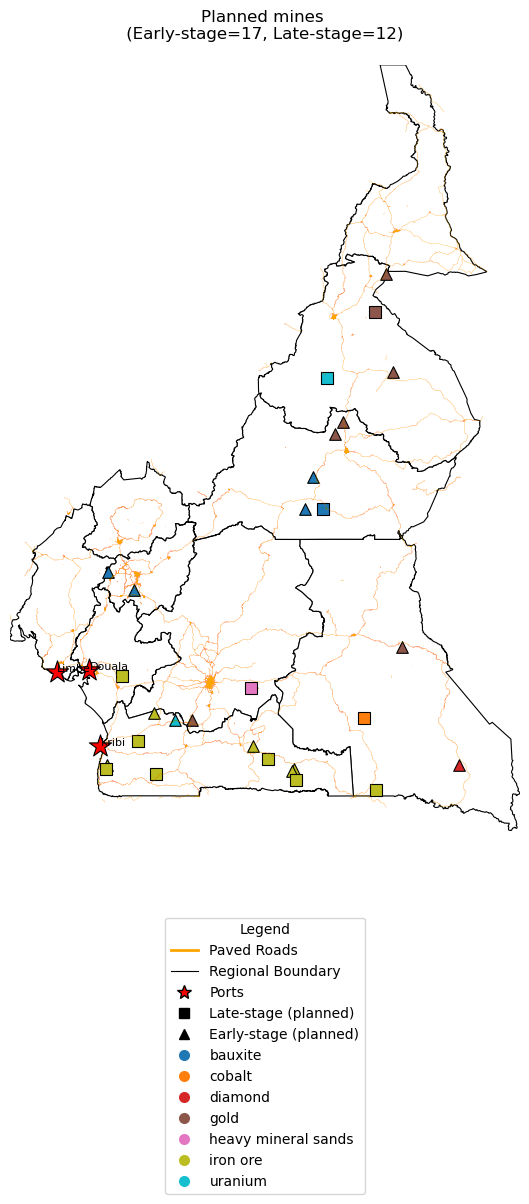

In [23]:
# consistent colors by commodity
commodities = sorted(all_mines_gdf["PRIMARY_COMMODITY"].dropna().unique())
cmap = plt.cm.get_cmap("tab10", len(commodities))
commodity_colors = {c: cmap(i) for i, c in enumerate(commodities)}

fig, ax = plt.subplots(1, 1, figsize=(6, 10))

# common map extent
xmin, ymin, xmax, ymax = adm1.total_bounds

# base layers
adm1.plot(ax=ax, color="white", edgecolor="black", linewidth=0.8)

main_roads = cameroon_roads[cameroon_roads["Surface"] == "paved"]
main_roads.plot(ax=ax, color="orange", linewidth=0.2, label="Paved Roads")

# protected_areas_gdf.plot(ax=ax, color="#00b777", edgecolor="#00b777", alpha=0.3, label="Protected Areas")

planned_early = all_mines_gdf[all_mines_gdf["DEV_STAGE_AGGREGATED_SNL"] == "Early-stage"]
for c in commodities:
    s = planned_early[planned_early["PRIMARY_COMMODITY"] == c]
    if not s.empty:
        s.plot(ax=ax, color=commodity_colors[c], markersize=70, marker="^", edgecolor="black", linewidth=0.8)

planned_late = all_mines_gdf[all_mines_gdf["DEV_STAGE_AGGREGATED_SNL"] == "Late-stage"]
for c in commodities:
    s = planned_late[planned_late["PRIMARY_COMMODITY"] == c]
    if not s.empty:
        s.plot(ax=ax, color=commodity_colors[c], markersize=70, marker="s", edgecolor="black", linewidth=0.8)

# ports
for name, (lat, lon) in port_locations.items():
    ax.scatter(
        lon, lat,
        marker="*",
        s=280,
        color="red",
        edgecolors="black",
        linewidths=0.8,
        zorder=6
    )
    ax.text(lon, lat, name, fontsize=8, color="black", zorder=7)

ax.set_title(
    f"Planned mines \n (Early-stage={len(planned_early)}, Late-stage={len(planned_late)}) \n",
    fontsize=12
)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.axis("off")

# legend
commodity_handles = [
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=commodity_colors[c],
               markersize=9, label=c)
    for c in commodities
]
shape_handles = [
    plt.Line2D([0], [0], marker="s", color="black", linestyle="None", markersize=7, label="Late-stage (planned)"),
    plt.Line2D([0], [0], marker="^", color="black", linestyle="None", markersize=7, label="Early-stage (planned)"),
]
road_handles = [plt.Line2D([0], [0], color="orange", linewidth=2, linestyle="-", label="Paved Roads")]
region_handles = [plt.Line2D([0], [0], color="black", linewidth=0.8, linestyle="-", label="Regional Boundary")]
# protected_area_handles = [plt.Line2D([0], [0], color="#00b777", alpha=0.3, linewidth=10, linestyle="-", label="Protected Areas")]
port_handles = [plt.Line2D([0], [0], marker="*", color="w", markerfacecolor="red",
                           markeredgecolor="black", markersize=10, linestyle="None", label="Ports")]

all_handles = road_handles + region_handles + port_handles + shape_handles + commodity_handles
all_labels = [h.get_label() for h in all_handles]

plt.tight_layout(rect=[0, 0.12, 1, 0.98])
plt.subplots_adjust(bottom=0.18)

fig.legend(
    handles=all_handles,
    labels=all_labels,
    title="Legend",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.1),  # 0.01 puts it just below the axes
    ncol=1,
    frameon=True
)
plt.show()


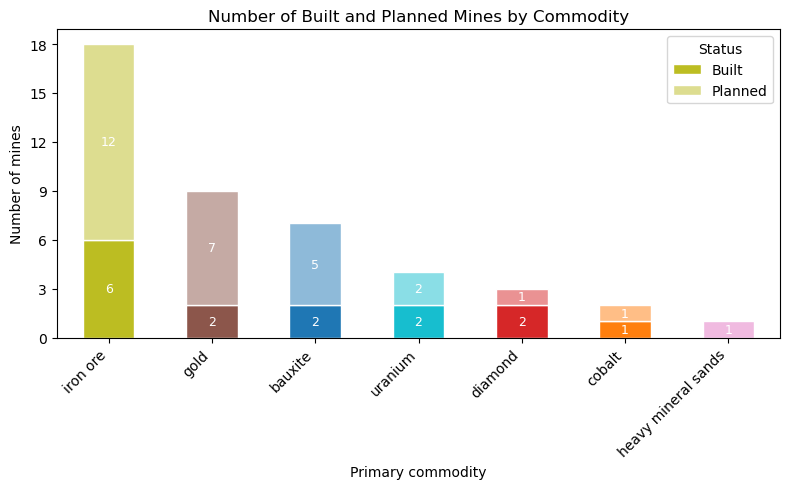

In [15]:
### create a stacked bar chart to show the number of built mines and planned mines by commodity type ###
# group the all_mines_df by 'PRIMARY_COMMODITY' and 'planned_mine' and count the number of mines in each group
mine_counts = (
    all_mines_df.groupby(["PRIMARY_COMMODITY", "planned_mine"])
    .size()
    .unstack(fill_value=0)
)

# sort commodities by total number of mines (planned + built), descending
mine_counts = mine_counts.loc[mine_counts.sum(axis=1).sort_values(ascending=False).index]

ax = mine_counts.plot(kind="bar", stacked=True, figsize=(8, 5))

# color bars by commodity (same as map): built=full color, planned=lighter (alpha=0.5)
status_cols = list(mine_counts.columns)  # typically [0, 1]

for ci, container in enumerate(ax.containers):
    status = status_cols[ci]  # 0=built, 1=planned
    for patch, commodity in zip(container.patches, mine_counts.index):
        base_color = commodity_colors.get(commodity, "gray")
        r, g, b, _ = plt.matplotlib.colors.to_rgba(base_color)
        alpha = 1.0 if status == 0 else 0.5
        patch.set_facecolor((r, g, b, alpha))
        patch.set_edgecolor("white")

# optional: clearer legend labels for built_mine values (0=built, 1=planned)
ax.legend(["Built", "Planned"], title="Status")

# label each stack segment with its count
for container in ax.containers:
    labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=9, color="white")

plt.ylabel("Number of mines")
plt.xlabel("Primary commodity")
plt.xticks(rotation=45, ha="right")
plt.yticks(range(0, 19, 3))
plt.title("Number of Built and Planned Mines by Commodity")
plt.tight_layout()

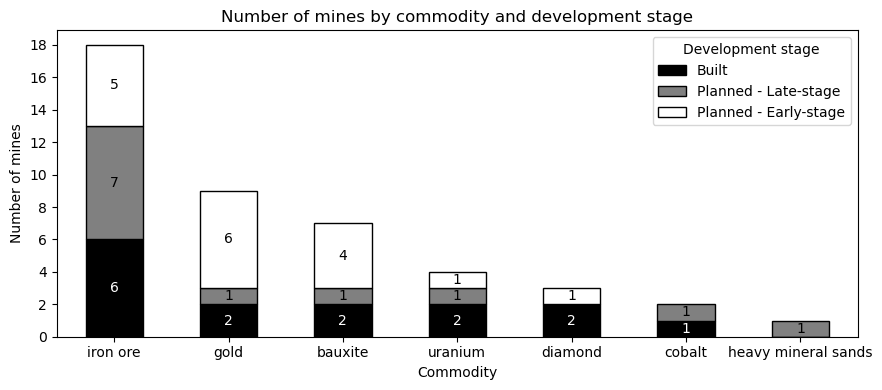

In [18]:
mine_counts = (
    all_mines_df.groupby(["PRIMARY_COMMODITY", "DEV_STAGE_AGGREGATED_SNL"])
    .size()
    .unstack(fill_value=0)
)

# enforce stack order: bottom -> top
stage_order = ["Mine-stage", "Late-stage", "Early-stage"]
mine_counts = mine_counts.reindex(columns=stage_order, fill_value=0)

# sort commodities by total mines (descending)
mine_counts = mine_counts.loc[mine_counts.sum(axis=1).sort_values(ascending=False).index]

ax = mine_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 4),
    color="white",      # base; overridden below
    edgecolor="black",
    linewidth=1.0
)

# monochrome/pattern styles by stage
stage_styles = {
    "Mine-stage": {"facecolor": "black", "hatch": ""},
    "Late-stage": {"facecolor": "grey", "hatch": ""},
    "Early-stage": {"facecolor": "white", "hatch": ""},
}

# apply styles to each stack layer (container order follows column order)
for ci, container in enumerate(ax.containers):
    stage = stage_order[ci]
    style = stage_styles[stage]
    for patch in container.patches:
        patch.set_facecolor(style["facecolor"])
        patch.set_hatch(style["hatch"])
        patch.set_edgecolor("black")

# labels on stacks
for ci, container in enumerate(ax.containers):
    stage = stage_order[ci]
    txt_color = "white" if stage == "Mine-stage" else "black"
    labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=10, color=txt_color)

# custom legend in desired order
legend_handles = [
    plt.matplotlib.patches.Patch(facecolor="black", edgecolor="black", label="Built"),
    plt.matplotlib.patches.Patch(facecolor="grey", edgecolor="black", hatch="", label="Planned - Late-stage"),
    plt.matplotlib.patches.Patch(facecolor="white", edgecolor="black", hatch="", label="Planned - Early-stage"),
]
ax.legend(handles=legend_handles, title="Development stage", loc="upper right")

plt.ylabel("Number of mines")
plt.xlabel("Commodity")
plt.xticks(rotation=0, ha="center", wrap=True)
plt.yticks(range(0, 20, 2))
plt.title("Number of mines by commodity and development stage")
plt.tight_layout()
